In [94]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [95]:
df = pd.read_csv("IMDB Dataset.csv")

In [96]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [97]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'I\'ve got to say it. Gary Busey saved this film. If it were not for his fine acting talents this film would have been sub par. I recommend the film but just barely.<br /><br />The biggest difficulty with the film is its broad disregard for historical, geographical and physical accuracy. For example, why is Lubbock green and hilly? How come Buddy\'s producer Petty ignored? Where are the daily trips to the Clovis, New Mexico studio? Why is Nashville treated as a racist hate camp out to destroy the Holly sound? Why was Buddy\'s two week courtship to Maria treated as a complex, taboo, race mixing stereotype? Why are Buddy\'s tile boxes as light as feathers? Finally, why are the Crickets portrayed as trouble making roadblocks to Holly\'s talent?<br /><br />Taken on their face these inaccuracies should spell doom for any film proclaiming itself, "The Buddy Holly Story." However, Busey does deliver a stirring portrayal as the man whose death eventually led to the day the music died.'

In [98]:
print(preprocess(df.iloc[random_num]['review']))

got say gary busey saved film fine acting talent film would sub par recommend film barely biggest difficulty film broad disregard historical geographical physical accuracy example lubbock green hilly come buddy producer petty ignored daily trip clovis new mexico studio nashville treated racist hate camp destroy holly sound buddy two week courtship maria treated complex taboo race mixing stereotype buddy tile box light feather finally cricket portrayed trouble making roadblock holly talent taken face inaccuracy spell doom film proclaiming buddy holly story however busey deliver stirring portrayal man whose death eventually led day music died


In [99]:
df['review'] = df['review'].apply(preprocess)

In [100]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [101]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [103]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [104]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [105]:
max_len = 5

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [106]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(2, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 5, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 2)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,073 (312.79 KB)

 Trainable params: 80,073 (312.79 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [108]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5002 - loss: 0.6930 - val_accuracy: 0.5336 - val_loss: 0.6925 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5328 - loss: 0.6900 - val_accuracy: 0.6607 - val_loss: 0.6810 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5781 - loss: 0.6668 - val_accuracy: 0.6804 - val_loss: 0.6346 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6130 - loss: 0.6433 - val_accuracy: 0.6859 - val_loss: 0.6118 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6352 - loss: 0.6281 - val_accuracy: 0.6917 - val_loss: 0.5995 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6416 - loss: 0.6164 - val_accuracy: 0.6960 - val_loss: 0.5907 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

In [109]:
#lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [110]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [111]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [112]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6810 - loss: 0.6061
Test Accuracy: 0.6809999942779541


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


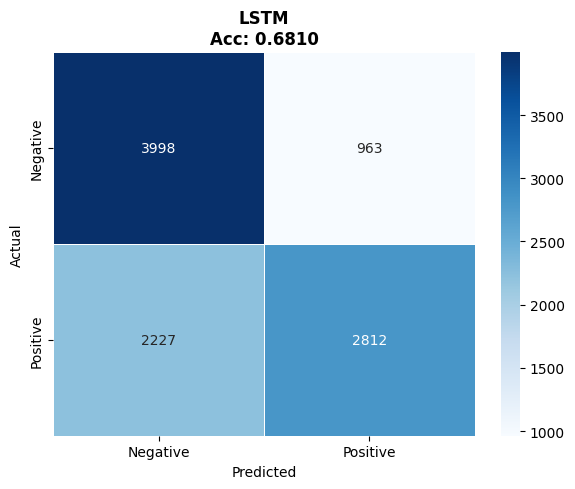

In [113]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [114]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.64      0.81      0.71      4961
    Positive       0.74      0.56      0.64      5039

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



# Teste de Outputs


In [115]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplest_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Outputs salvos em layer_outputs_simplest_model.txt


In [130]:
from functions import *

# Exportação de Pesos

In [131]:
export_weights(lstm_model, mode='lstm', output_file="../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.380172
  addr=0x08001 Wx_input[0][1] = -0.298270
  addr=0x08080 Wx_input[1][0] = -0.401379
  addr=0x08081 Wx_input[1][1] = -0.447374
  addr=0x08040 Wh_input[0][0] = -0.699953
  addr=0x08041 Wh_input[0][1] = 0.155140
  addr=0x080C0 Wh_input[1][0] = -0.386296
  addr=0x080C1 Wh_input[1][1] = 0.370060
  addr=0x18000 bias_input[0] = 0.477554
  addr=0x18080 bias_input[1] = 0.493915
  addr=0x0A000 Wx_forget[0][0] = -1.316254
  addr=0x0A001 Wx_forget[0][1] = -0.447601
  addr=0x0A080 Wx_forget[1][0] = -0.838208
  addr=0x0A081 Wx_forget[1][1] = -1.176593
  addr=0x0A040 Wh_forget[0][0] = -0.746099
  addr=0x0A041 Wh_forget[0][1] = -0.268101
  addr=0x0A0C0 Wh_forget[1][0] = 0.255389
  addr=0x0A0C1 Wh_forget[1][1] = 0.332163
  addr=0x1A000 bias_forget[0] = 1.156950
  addr=0x1A080 bias_forget[1] = 1.027289
  addr=0x0C000 Wx_candidate[0][0] = 1.024790
  addr=

# Teste Global

In [117]:
FRAC = 24
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q24(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [118]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q24 = float_to_q24(valor)  # sua função original
            mem[addr] = valor_q24
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q24(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [119]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 50

valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_0.mem
0 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_1.mem
1 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_2.mem
2 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_3.mem
3 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_4.mem
4 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_5.mem
5 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46

In [127]:
out_verilog=pd.read_csv("resultados_lstm2.txt",skiprows=3,header=None,sep=" ")[12]
out_verilog 

0     0.127866
1    -0.239902
2    -0.184946
3     0.230206
4    -0.328604
        ...   
95    0.380087
96   -0.337964
97    0.364549
98    0.098937
99   -0.130494
Name: 12, Length: 100, dtype: float64

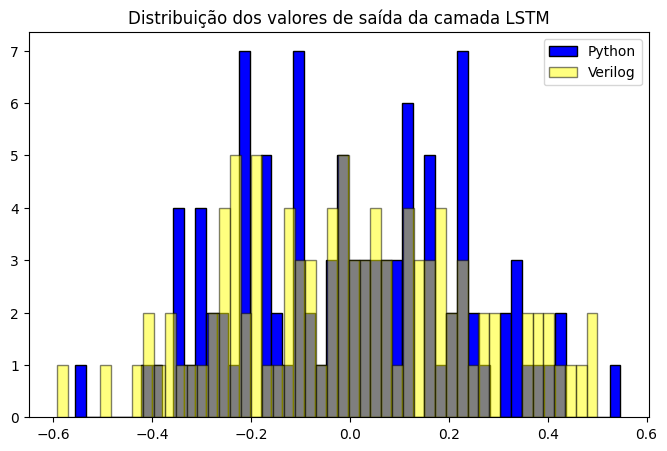

In [128]:
plt.figure(figsize=(8,5))

plt.hist(
    valores_out_lstm,
    bins=50,
    color=(0, 0, 1),
    alpha=1,
    edgecolor='black',
    label='Python'
)

plt.hist(
    out_verilog,
    bins=50,
    color='yellow',
    alpha=0.5,
    edgecolor='black',
    label='Verilog'
)

plt.title("Distribuição dos valores de saída da camada LSTM")
plt.legend()
plt.show()

R² = 0.970331


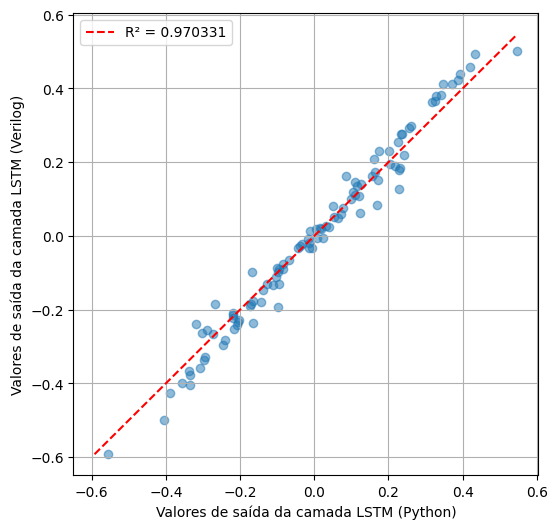

In [129]:

from sklearn.metrics import r2_score

plt.figure(figsize=(6,6))

plt.scatter(valores_out_lstm, out_verilog, alpha=0.5)

# reta y = x
lim_min = min(np.min(valores_out_lstm), np.min(out_verilog))
lim_max = max(np.max(valores_out_lstm), np.max(out_verilog))
r2 = r2_score(valores_out_lstm, out_verilog)
print(f"R² = {r2:.6f}")
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label=f'R² = {r2:.6f}')

# R²


plt.xlabel("Valores de saída da camada LSTM (Python)")
plt.ylabel("Valores de saída da camada LSTM (Verilog)")
plt.legend()
plt.grid(True)
plt.show()

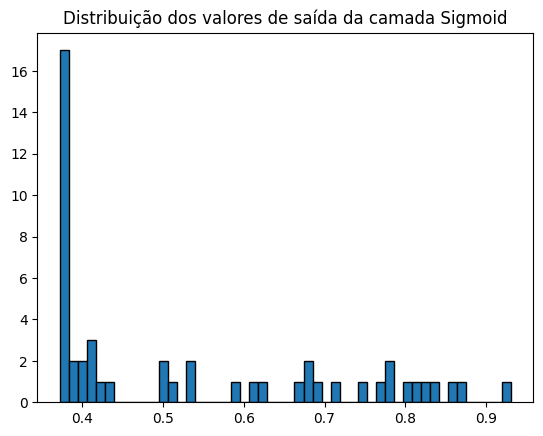

In [123]:
plt.title("Distribuição dos valores de saída da camada Sigmoid")
plt.hist(valores_out_sigmoid, bins=50, edgecolor='black')
plt.show()

In [124]:
dado = pd.read()

AttributeError: module 'pandas' has no attribute 'read'

In [134]:
import numpy as np

# ============================================================
# CONSTANTES Q8.24
# ============================================================
FRAC = 24
SCALE = 1 << FRAC  # 2^24 = 16777216

def q24_to_float(q_val):
    """Converte Q8.24 para float32"""
    # Se for negativo (bit 31 = 1), faz o sinal
    if q_val >= 0x80000000:
        q_val = q_val - 0x100000000
    return q_val / SCALE

# ============================================================
# LEITURA SIMPLES DOS ARQUIVOS
# ============================================================
for i in range(1):
    arquivo = f"../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_{i}.mem"
    
    try:
        with open(arquivo, "r") as f:
            linhas = f.readlines()
        
        # Pula linhas vazias
        linhas = [l.strip() for l in linhas if l.strip()]
        
        print(f"\nArquivo {i}: {len(linhas)} linhas")
        
        # Primeira linha (especial)
        primeira = linhas[0].split()
        if len(primeira) >= 4:
            addr = int(primeira[0], 16)
            data = int(primeira[1], 16)
            python_result = int(primeira[2], 16)
            gt = int(primeira[3], 16)
            
            print(f"  Python result: {q24_to_float(python_result):.6f}")
            print(f"  Ground truth: {gt}")
            print(f"  Primeiro dado: addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
        # Mostra os primeiros 5 dados normais
        print(f"  Primeiros dados (Q8.24 -> float):")
        for j in range(1, min(6, len(linhas))):
            partes = linhas[j].split()
            if len(partes) >= 2:
                addr = int(partes[0], 16)
                data = int(partes[1], 16)
                print(f"    [{j}] addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
    except FileNotFoundError:
        print(f"Arquivo {i} não encontrado")
        break
    except Exception as e:
        print(f"Erro no arquivo {i}: {e}")


Arquivo 0: 20 linhas
  Python result: 0.373072
  Ground truth: 1
  Primeiro dado: addr=0x00000, data=0.182690
  Primeiros dados (Q8.24 -> float):
    [1] addr=0x00001, data=0.155404
    [2] addr=0x00002, data=0.205526
    [3] addr=0x00003, data=-0.149686
    [4] addr=0x00004, data=0.143018
    [5] addr=0x00005, data=0.194240
